## 

## Import

In [22]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
claimants_data=pd.read_csv("Claimants.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## Data Understanding

In [4]:
claimants_data.shape

(1340, 7)

In [5]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [6]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

## Data Cleaning

In [9]:
claimants_data=claimants_data.dropna()
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## Data Preparation

In [11]:
X=claimants_data.drop(labels=["CASENUM","ATTORNEY"],axis=1)
Y=claimants_data["ATTORNEY"]

## Model Building

In [23]:
X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,shuffle=True)


In [24]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
444,1.0,1.0,0.0,10.0,3.064
149,1.0,1.0,0.0,10.0,0.443
945,0.0,1.0,0.0,18.0,3.365
1117,1.0,1.0,0.0,14.0,5.830
159,0.0,0.0,0.0,51.0,0.050
...,...,...,...,...,...
727,0.0,1.0,0.0,10.0,3.974
415,0.0,1.0,0.0,48.0,68.548
1202,1.0,1.0,0.0,11.0,0.436
276,1.0,1.0,0.0,37.0,4.018


In [25]:
X_test

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
940,0.0,1.0,0.0,53.0,0.000
320,1.0,1.0,0.0,48.0,0.470
281,0.0,1.0,0.0,38.0,1.031
957,0.0,1.0,0.0,34.0,0.495
1108,0.0,1.0,0.0,54.0,0.748
...,...,...,...,...,...
232,1.0,1.0,0.0,34.0,4.090
1220,1.0,1.0,0.0,47.0,0.600
709,0.0,1.0,0.0,57.0,1.019
939,1.0,1.0,0.0,31.0,1.486


In [26]:
y_train

444     0
149     1
945     1
1117    0
159     1
       ..
727     1
415     0
1202    1
276     0
995     0
Name: ATTORNEY, Length: 876, dtype: int64

In [27]:
y_test

940     1
320     1
281     1
957     0
1108    1
       ..
232     1
1220    1
709     1
939     1
255     0
Name: ATTORNEY, Length: 220, dtype: int64

In [14]:
logistic_model=LogisticRegression()

## Model Training

In [95]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,VotingClassifier

In [96]:
rf_classifier=RandomForestClassifier()

In [97]:
rf_classifier.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
ada_classfier=AdaBoostClassifier()

In [67]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [84]:
dt_model=DecisionTreeClassifier()

In [71]:
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [72]:
dt_model.fit(X_test,y_test)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.8333333333333334, 'x[4] <= 1.071\ngini = 0.499\nsamples = 220\nvalue = [104.0, 116.0]'),
 Text(0.25, 0.5, 'x[3] <= 6.5\ngini = 0.351\nsamples = 119\nvalue = [27, 92]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.477\nsamples = 28\nvalue = [11, 17]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.29\nsamples = 91\nvalue = [16, 75]'),
 Text(0.75, 0.5, 'x[4] <= 8.278\ngini = 0.362\nsamples = 101\nvalue = [77, 24]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.402\nsamples = 86\nvalue = [62.0, 24.0]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]')]

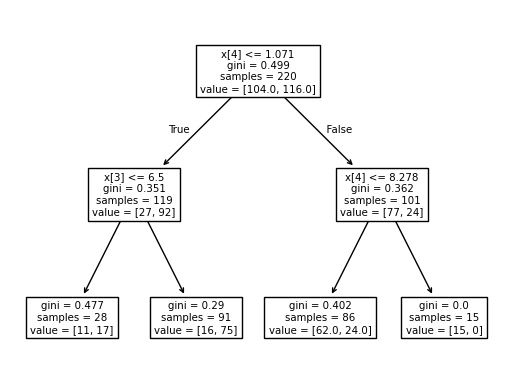

In [68]:
plot_tree(dt_model)

In [69]:
from sklearn.model_selection import GridSearchCV

In [87]:
dt_model=DecisionTreeClassifier()

In [105]:
grid_search=GridSearchCV(rf_classifier,param_grid={"max_depth":[4,5,6,7,8,9]})

In [106]:
grid_search.fit(X,Y)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [4, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [107]:
grid_search.best_params_

{'max_depth': 4}

In [94]:
grid_search.best_params_

{'max_depth': 4}

In [28]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Tetsing

In [32]:
logistic_model.predict(X_train)



array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,

## Model Evaluation

In [98]:
y_pred_test=rf_classifier.predict(X_test)
y_pred_train=rf_classifier.predict(X_train)

In [55]:
y_pred_test

array([1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0])

In [56]:
y_pred_train

array([0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,

In [99]:
confusion_matrix(y_train,y_pred_train)

array([[472,   2],
       [  1, 401]])

In [57]:
confusion_matrix(y_test,y_pred_test)

array([[71, 33],
       [44, 72]])

In [100]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       474
           1       1.00      1.00      1.00       402

    accuracy                           1.00       876
   macro avg       1.00      1.00      1.00       876
weighted avg       1.00      1.00      1.00       876



In [101]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.64      0.72      0.68       104
           1       0.72      0.63      0.67       116

    accuracy                           0.67       220
   macro avg       0.68      0.68      0.67       220
weighted avg       0.68      0.67      0.67       220



In [39]:
y_pred_test=logistic_model.predict(X_test)
y_pred_train=logistic_model.predict(X_train)
accuracy_score(y_test,y_pred_test)

0.7272727272727273

In [38]:
from sklearn.metrics import classification_report,confusion_matrix,auc,roc_auc_score,roc_curve

In [40]:
confusion_matrix(y_train,y_pred_train)

array([[318, 156],
       [104, 298]])

In [41]:
confusion_matrix(y_test,y_pred_test)

array([[70, 34],
       [26, 90]])

In [43]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.67      0.71       474
           1       0.66      0.74      0.70       402

    accuracy                           0.70       876
   macro avg       0.70      0.71      0.70       876
weighted avg       0.71      0.70      0.70       876



In [44]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.73      0.67      0.70       104
           1       0.73      0.78      0.75       116

    accuracy                           0.73       220
   macro avg       0.73      0.72      0.72       220
weighted avg       0.73      0.73      0.73       220



In [46]:
roc_auc_score(y_test,y_pred_test)

0.7244694960212202

In [49]:
roc_curve(y_test,y_pred_test)

(array([0.        , 0.32692308, 1.        ]),
 array([0.        , 0.77586207, 1.        ]),
 array([inf,  1.,  0.]))

## Model Deployment

In [21]:
from pickle import dump
dump(logistic_model,open("claimants.pkl","wb"))
